In [63]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torchaudio as ta
import torch

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
root = Path(r"D:\segs_clust_1734")
graph_path = r"C:\Users\Lindholm\Documents\BSc\bsc_project\research\graphs\graphs_wk12"

pc = 2
k = 8

pc_dir  = root / f"pc_{pc:03d}"
kdir    = pc_dir / f"k_{k:02d}"

Z2  = np.load(pc_dir / "pca2_scores.npy")          # (N,2)
labs = np.load(kdir / "segment_labels.npy")        # (N,)
cent = np.load(kdir / "kmeans_centers.npy")        # (k, pc)

ipca = np.load(root / "segments_ipca.npz")
C = ipca["ipca_components"][:2]        # shape (2, D_ipca)
cent2 = cent[:, :2] @ np.eye(2)        # already in PC space when pc=2

# cent: (k, n_components)
# for any n_components, centroids in PCA(2) are:
C2 = ipca["ipca_components"][:2]       # (2, D)
mean = ipca["ipca_mean"]               # (D,)
cent_full = cent @ ipca["ipca_components"][:cent.shape[1], :]  # back to feature space
cent2 = (cent_full - mean) @ C2.T

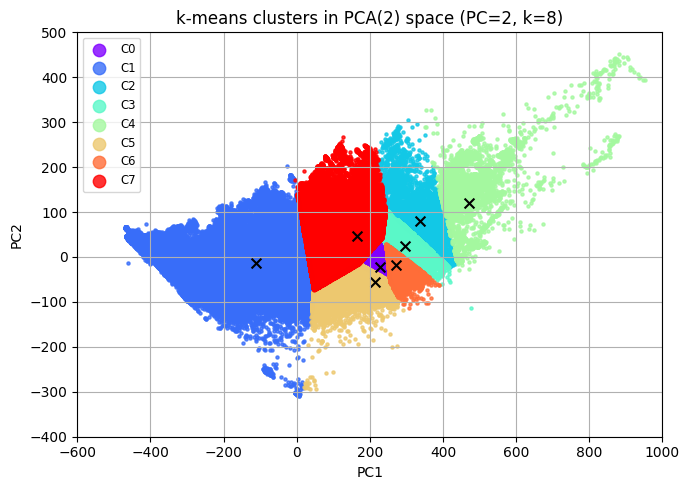

In [24]:
fig, ax = plt.subplots(figsize=(7,5))
plt.get_cmap("rainbow")
colors = plt.cm.rainbow(np.linspace(0, 1, k))
for j in range(k):
    idx = (labs == j)
    ax.scatter(Z2[idx,0], Z2[idx,1], s=5, alpha=0.8, label=f"C{j}", color=colors[j])

ax.scatter(cent2[:,0], cent2[:,1], s=50, c="black", marker="x")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"k-means clusters in PCA(2) space (PC={pc}, k={k})")
ax.set_xlim(-600, 1000)
ax.set_ylim(-400, 500)
ax.legend(loc="upper left", fontsize="small", markerscale=4)
ax.grid(True)
plt.tight_layout()
plt.savefig(Path(graph_path) / f"pc{pc}_k{k}_clusters.png", dpi=300)
plt.show()


In [28]:
def print_segment_stats(out_root, pc, k):
    pc_dir  = root / f"pc_{pc:03d}"
    kdir    = pc_dir / f"k_{k:02d}"

    # PCA scores
    Z_opt = np.load(pc_dir / "pca_scores.npy")      # (N, n_pc)
    Z2    = np.load(pc_dir / "pca2_scores.npy")     # (N, 2)

    # Clustering outputs
    labels = np.load(kdir / "segment_labels.npy")   # (N,)
    dist2  = np.load(kdir / "segment_dist2.npy")    # (N,)
    meta   = np.load(kdir / "segment_meta.npy")     # structured array
    summ   = np.load(kdir / "kmeans_summary.npz")   # inertia, silhouette, etc.

    # Scaler: tells us the original flattened feature dimension D
    scaler = np.load(out_root / "segments_scaler.npz")
    D = scaler["mean"].shape[0]

    N = Z_opt.shape[0]
    n_pc = Z_opt.shape[1]

    print("=== Global stats ===")
    print(f"Number of segments N        : {N}")
    print(f"PCA dimension (n_components): {n_pc}")
    print(f"Original flattened dim D    : {D}")
    print(f"PCA(2) shape                : {Z2.shape}")

    print("\n=== Cluster stats ===")
    unique, counts = np.unique(labels, return_counts=True)
    for c, n in zip(unique, counts):
        print(f"Cluster {c:2d}: {n} segments")
    print(f"Total clusters k            : {len(unique)}")

    print("\n=== Distance stats (squared distance to centroid) ===")
    print(f"mean(dist^2) : {dist2.mean():.3e}")
    print(f"std(dist^2)  : {dist2.std():.3e}")
    print(f"min(dist^2)  : {dist2.min():.3e}")
    print(f"max(dist^2)  : {dist2.max():.3e}")

    print("\n=== k-means summary ===")
    print(f"inertia      : {float(summ['inertia']):.3e}")
    print(f"silhouette   : {float(summ['silhouette']):.4f}")
    print(f"n_pc (saved) : {int(summ['n_pc'])}")
    print(f"k (saved)    : {int(summ['k'])}")

    print("\n=== Segment metadata ===")
    file_paths = meta['file_path']
    unique_files = np.unique(file_paths)
    print(f"Number of source files      : {len(unique_files)}")

    # segments per file (top few)
    print("\nSegments per file (top 10):")
    from collections import Counter
    c = Counter(file_paths)
    for fp, n in list(c.items())[:10]:
        print(f"{n:5d} segments  | {fp}")


In [30]:
print_segment_stats(out_root=root, pc=2, k=8)

=== Global stats ===
Number of segments N        : 653130
PCA dimension (n_components): 2
Original flattened dim D    : 72947
PCA(2) shape                : (653130, 2)

=== Cluster stats ===
Cluster  0: 42728 segments
Cluster  1: 266913 segments
Cluster  2: 17327 segments
Cluster  3: 30512 segments
Cluster  4: 5974 segments
Cluster  5: 96591 segments
Cluster  6: 23798 segments
Cluster  7: 169287 segments
Total clusters k            : 8

=== Distance stats (squared distance to centroid) ===
mean(dist^2) : 2.564e+04
std(dist^2)  : 6.207e+04
min(dist^2)  : 0.000e+00
max(dist^2)  : 2.245e+06

=== k-means summary ===
inertia      : 5.001e+08
silhouette   : 0.8497
n_pc (saved) : 2
k (saved)    : 8

=== Segment metadata ===
Number of source files      : 12095

Segments per file (top 10):
   54 segments  | /home/trh104/second_extraction/Aug_6229/6229.220802122000.npz
   54 segments  | /home/trh104/second_extraction/Aug_6229/6229.220802124000.npz
   54 segments  | /home/trh104/second_extraction

In [60]:
out_root = root
feat_root = Path(r"D:\second_extraction\Aug_6229")
pc = 2
k = 8
drop_mels = 9      # must match the program config

pc_dir = out_root / f"pc_{pc:03d}"
kdir   = pc_dir / f"k_{k:02d}"

# Load arrays
Z_opt  = np.load(pc_dir / "pca_scores.npy")      # (N, pc)
Z2     = np.load(pc_dir / "pca2_scores.npy")     # (N, 2)
labels = np.load(kdir / "segment_labels.npy")   # (N,)
dist2  = np.load(kdir / "segment_dist2.npy")    # (N,)
meta   = np.load(kdir / "segment_meta.npy")     # structured array

def print_segment_info(i: int):
    """Prints all info we have about segment i and its raw feature segment."""
    # --- indexing into saved arrays ---
    lab_i   = int(labels[i])
    d2_i    = float(dist2[i])
    z_i     = Z_opt[i]     # PC coordinates (pc dim)
    z2_i    = Z2[i]        # 2D projection

    m_i     = meta[i]
    file_i  = m_i["file_path"]
    file_i  = feat_root / Path(file_i).stem
    file_i = str(file_i) + ".npz"
    seg_idx = int(m_i["segment_idx"])
    s       = int(m_i["start_frame"])
    e       = int(m_i["end_frame"])

    print("=== Segment index in dataset ===")
    print(f"global index i      : {i}")
    print(f"source file         : {file_i}")
    print(f"segment_idx in file : {seg_idx}")
    print(f"start_frame         : {s}")
    print(f"end_frame           : {e}")
    print(f"num_frames          : {e - s}")

    print("\n=== Clustering info ===")
    print(f"cluster label       : {lab_i}")
    print(f"squared distance d² : {d2_i:.3e}")

    print("\n=== PCA coordinates ===")
    print(f"Z_opt[i].shape      : {z_i.shape}")
    print(f"Z_opt[i]            : {z_i}")
    print(f"Z2[i] (PC1, PC2)    : {z2_i}")

    # --- load original feature segment from the .npz file ---
    with np.load(file_i, mmap_mode="r") as z:
        feat = np.squeeze(z["feature"])          # (M, T_full)
        M, T_full = feat.shape
        seg = feat[drop_mels:, s:e]              # (M - drop_mels, T_seg)

    print("\n=== Original feature segment (log-mel) ===")
    print(f"full feature shape  : {feat.shape}       # (M, T_full)")
    print(f"segment shape       : {seg.shape}        # (M - drop_mels, T_seg)")
    print(f"segment min / max   : {seg.min():.3f}, {seg.max():.3f}")
    print("segment[0, :10]     :", seg[0, :10])      # small preview

In [61]:
print_segment_info(0)


=== Segment index in dataset ===
global index i      : 0
source file         : D:\second_extraction\Aug_6229\6229.220802122000.npz
segment_idx in file : 0
start_frame         : 0
end_frame           : 613
num_frames          : 613

=== Clustering info ===
cluster label       : 1
squared distance d² : 1.282e+05

=== PCA coordinates ===
Z_opt[i].shape      : (2,)
Z_opt[i]            : [-462.229      58.973663]
Z2[i] (PC1, PC2)    : [-462.229      58.973663]

=== Original feature segment (log-mel) ===
full feature shape  : (128, 33125)       # (M, T_full)
segment shape       : (119, 613)        # (M - drop_mels, T_seg)
segment min / max   : -100.000, -39.918
segment[0, :10]     : [-49.34708  -41.336105 -69.26576  -47.558178 -54.013844 -49.366432
 -47.754204 -54.95802  -46.887657 -59.22922 ]


## Query for validation sample

In [62]:
pc = 2
k  = 8

pc_dir = out_root / f"pc_{pc:03d}"
kdir   = pc_dir / f"k_{k:02d}"

meta   = np.load(kdir / "segment_meta.npy")      # structured array
labels = np.load(kdir / "segment_labels.npy")    # (N,)
Z_opt  = np.load(pc_dir / "pca_scores.npy")      # (N, pc)
Z2     = np.load(pc_dir / "pca2_scores.npy")     # (N, 2)

target_stub = "6230.220917120000"

# Option 1: match by substring (robust if path has dirs, .npz, etc.)
mask = np.char.find(meta["file_path"].astype(str), target_stub) >= 0

# Option 2 (stricter): match exact filename ending
# mask = np.char.endswith(meta["file_path"].astype(str), target_stub + ".npz")

idx = np.where(mask)[0]      # indices of segments from that file
print(f"#segments from {target_stub}: {len(idx)}")

# Slice all arrays for those segments
meta_sub   = meta[idx]
labels_sub = labels[idx]
Z_opt_sub  = Z_opt[idx]
Z2_sub     = Z2[idx]

# Inspect a few entries
for i, gi in enumerate(idx[:10]):   # first 10 segments from that file
    m = meta[gi]
    print(f"\nSegment {i} (global idx {gi}):")
    print(f"  file_path   : {m['file_path']}")
    print(f"  segment_idx : {m['segment_idx']}")
    print(f"  start_frame : {m['start_frame']}")
    print(f"  end_frame   : {m['end_frame']}")
    print(f"  label       : {labels[gi]}")
    print(f"  Z2 (PC1,PC2): {Z2[gi]}")


#segments from 6230.220917120000: 54

Segment 0 (global idx 396792):
  file_path   : /home/trh104/second_extraction/Tracy_6230/6230.220917120000.npz
  segment_idx : 0
  start_frame : 0
  end_frame   : 613
  label       : 7
  Z2 (PC1,PC2): [141.33307 134.13991]

Segment 1 (global idx 396793):
  file_path   : /home/trh104/second_extraction/Tracy_6230/6230.220917120000.npz
  segment_idx : 1
  start_frame : 613
  end_frame   : 1226
  label       : 7
  Z2 (PC1,PC2): [116.6658   97.06528]

Segment 2 (global idx 396794):
  file_path   : /home/trh104/second_extraction/Tracy_6230/6230.220917120000.npz
  segment_idx : 2
  start_frame : 1226
  end_frame   : 1839
  label       : 7
  Z2 (PC1,PC2): [89.00876  72.359245]

Segment 3 (global idx 396795):
  file_path   : /home/trh104/second_extraction/Tracy_6230/6230.220917120000.npz
  segment_idx : 3
  start_frame : 1839
  end_frame   : 2452
  label       : 7
  Z2 (PC1,PC2): [119.03976  111.343025]

Segment 4 (global idx 396796):
  file_path   : /home/

In [68]:
val1_path = r"D:\second_extraction\Tracy_6230\6230.220917120000.npz"
s1 = np.load(val1_path)["feature"]

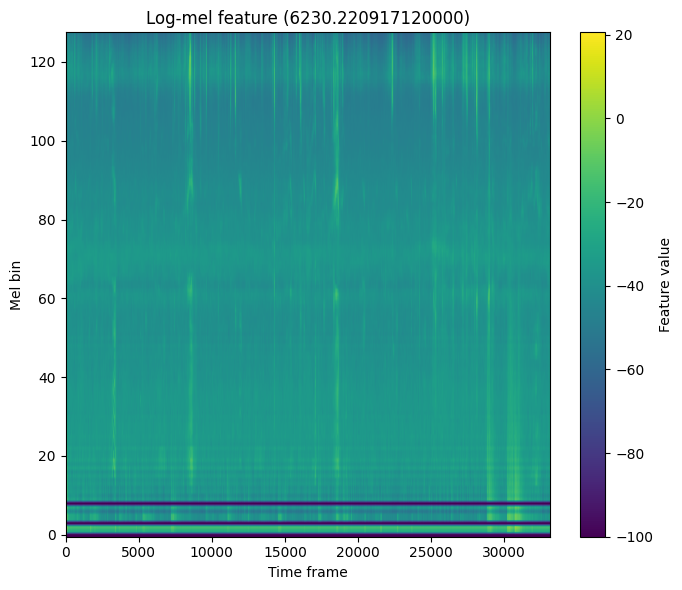

In [73]:
spec = s1[0]

plt.figure(figsize=(7, 6))
im = plt.imshow(
    spec,
    origin="lower",
    aspect="auto"
)
plt.colorbar(im, label="Feature value")
plt.xlabel("Time frame")
plt.ylabel("Mel bin")
plt.title("Log-mel feature (6230.220917120000)")
plt.tight_layout()
plt.show()

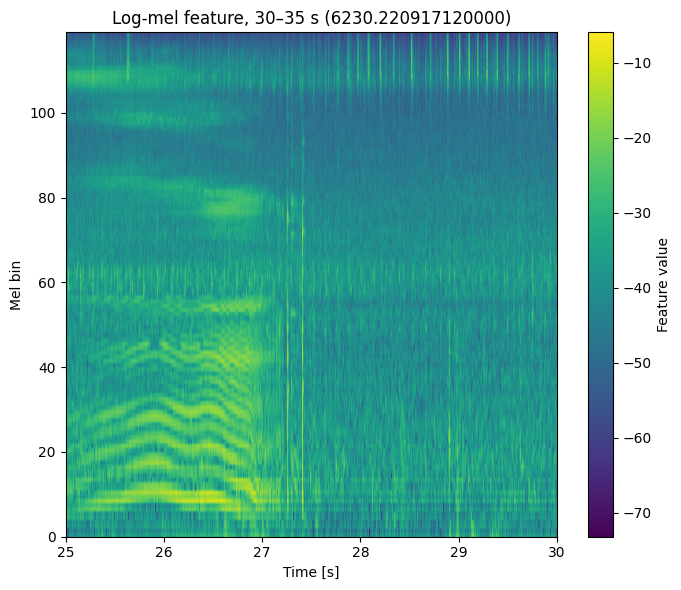

In [77]:
sr = 64000
hop_length = 512

fps = sr / hop_length

t_start, t_end = 25.0, 30.0
i_start = int(t_start * fps)
i_end   = int(t_end   * fps)

seg = spec[9:, i_start:i_end]

plt.figure(figsize=(7, 6))
im = plt.imshow(
    seg,
    origin="lower",
    aspect="auto",
    extent=[t_start, t_end, 0, seg.shape[0]]  # x-axis in seconds
)
plt.colorbar(im, label="Feature value")
plt.xlabel("Time [s]")
plt.ylabel("Mel bin")
plt.title("Log-mel feature, 30–35 s (6230.220917120000)")
plt.tight_layout()
plt.show()